In [ ]:
import numpy as np
import pandas as pd
from datetime import date, datetime
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error


In [ ]:
df = pd.read_csv('/content/Dataset.csv')

In [ ]:
df.columns

Index(['Timestamp', '1. Age: _______ (years)', '2. Gender:',
       '3. Relationship status:', '4. Current primary occupation:',
       '5. Primary work / activity setting:',
       ' 6. Do you currently use social media?',
       '7. Which social media platforms do you use regularly? (tick all that apply)',
       '8. Average time spent on social media per day:',
       '9. How often do you use social media without a specific purpose (mindless browsing)?',
       '10. How often do social media notifications or content distract you during important tasks (work, study, chores etc.)?',
       '11. When you haven’t used social media for a while, how restless or uneasy do you feel?',
       '12. What aspects of social media distract you the most? (tick all that apply)',
       '13. On a scale of 1–5, how strongly do these distractions affect your ability to focus?',
       '14. How often do you find it difficult to concentrate on tasks?( Using Social Media)',
       '15. On a typical day, 

In [ ]:
df.drop(['Timestamp'], inplace = True, axis = 1)

In [ ]:
df.drop(['23. Attention check: To ensure data quality, please select 3 for this question.'], inplace = True, axis = 1)

In [ ]:
df.drop(columns=["24. Optional: Anything else you'd like to share about your social media use and work–life balance?"], inplace=True)


In [ ]:
col_names_dict = {
    '1. Age: _______ (years)': 'age',
    '2. Gender:': 'gender',
    '3. Relationship status:': 'relationship_status',
    '4. Current primary occupation:': 'occupation_status',
    '5. Primary work / activity setting:': 'org_affiliation',

    ' 6. Do you currently use social media?': 'uses_social_media',
    '7. Which social media platforms do you use regularly? (tick all that apply)': 'platforms_used',
    '8. Average time spent on social media per day:': 'daily_time_spent',

    '9. How often do you use social media without a specific purpose (mindless browsing)?': 'mindless_use_freq',
    '10. How often do social media notifications or content distract you during important tasks (work, study, chores etc.)?': 'distraction_when_busy_freq',
    '11. When you haven’t used social media for a while, how restless or uneasy do you feel?': 'restless_without_sm',

    '12. What aspects of social media distract you the most? (tick all that apply)': 'top_distraction_sources',
    '13. On a scale of 1–5, how strongly do these distractions affect your ability to focus?': 'distraction_impact',
    '14. How often do you find it difficult to concentrate on tasks?( Using Social Media)': 'concentration_difficulty_freq',

    '15. On a typical day, how productive do you feel?': 'daily_productivity',
    '16. How often do you feel that social media negatively affects your productivity or performance?': 'sm_negative_impact_freq',

    '17. How often do you compare yourself with others on social media?': 'social_comparison_freq',
    '18. Overall, how do these comparisons make you feel?': 'comparison_feelings',
    '19. How often do you seek validation on social media (likes, comments, reactions)?': 'validation_seeking_freq',

    '20. Over the past two weeks, how often have you felt depressed, upset, or unusually sad?': 'low_mood_freq',
    '21. How often does your motivation or interest in daily activities fluctuate?': 'interest_fluctuation_freq',
    '22. How often do you experience sleep-related issues (difficulty falling or staying asleep)?': 'sleep_issues_freq',
}


In [ ]:
df.shape

(1005, 22)

In [ ]:
df.rename(columns=col_names_dict, inplace=True)
df.head(2).T

,0,1
age,27,25
gender,Female,Male
relationship_status,Single,In a relationship/ Married
occupation_status,Employee,Student
org_affiliation,Government / Semi-governmentCorporate / Private,NaN
uses_social_media,Yes,Yes
platforms_used,Facebook;Instagram;YouTube,Facebook;Instagram;YouTube
daily_time_spent,More than 4 hours,More than 4 hours
mindless_use_freq,Often,Often
distraction_when_busy_freq,Rarely,Always


In [ ]:
titles = list(df.columns)

In [ ]:
titles

['age',
 'gender',
 'relationship_status',
 'occupation_status',
 'org_affiliation',
 'uses_social_media',
 'platforms_used',
 'daily_time_spent',
 'mindless_use_freq',
 'distraction_when_busy_freq',
 'restless_without_sm',
 'top_distraction_sources',
 'distraction_impact',
 'concentration_difficulty_freq',
 'daily_productivity',
 'sm_negative_impact_freq',
 'social_comparison_freq',
 'comparison_feelings',
 'validation_seeking_freq',
 'low_mood_freq',
 'interest_fluctuation_freq',
 'sleep_issues_freq']

In [ ]:
sex = set(df['gender'])
print(sex)

{'Male', 'Prefer not to say', 'Female'}


In [ ]:
df['gender'].value_counts()

,count
gender,
Male,592
Female,409
Prefer not to say,4


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
relationship_status,0
occupation_status,0
org_affiliation,469
uses_social_media,0
platforms_used,2
daily_time_spent,9
mindless_use_freq,0
distraction_when_busy_freq,0


In [ ]:
df.loc[390,'age']

'27'

In [ ]:
print([f"Nan values in: {(element, value)}" for (element, value) in zip(df.isnull().sum().index, df.isnull().sum()) if value > 0])

["Nan values in: ('org_affiliation', 469)", "Nan values in: ('platforms_used', 2)", "Nan values in: ('daily_time_spent', 9)", "Nan values in: ('sleep_issues_freq', 5)"]


In [ ]:
f"Percent NaN = {df.org_affiliation.isnull().sum()/len(df.org_affiliation)*100:0.2f} %"

'Percent NaN = 46.67 %'

In [ ]:
df.org_affiliation.fillna(df['org_affiliation'].value_counts().index[0], inplace=True)

/tmp/ipykernel_852/163795634.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.org_affiliation.fillna(df['org_affiliation'].value_counts().index[0], inplace=True)


In [ ]:
f"Percent NaN = {df.platforms_used.isnull().sum()/len(df.platforms_used)*100:0.2f} %"

'Percent NaN = 0.20 %'

In [ ]:
df.platforms_used.fillna(df['platforms_used'].value_counts().index[0], inplace=True)

/tmp/ipykernel_852/3692215873.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.platforms_used.fillna(df['platforms_used'].value_counts().index[0], inplace=True)


In [ ]:
f"Percent NaN = {df.daily_time_spent.isnull().sum()/len(df.daily_time_spent)*100:0.2f} %"

'Percent NaN = 0.90 %'

In [ ]:
df.daily_time_spent.fillna(df['daily_time_spent'].value_counts().index[0], inplace=True)

/tmp/ipykernel_852/3249094752.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.daily_time_spent.fillna(df['daily_time_spent'].value_counts().index[0], inplace=True)


In [ ]:
f"Percent NaN = {df.sleep_issues_freq.isnull().sum()/len(df.sleep_issues_freq)*100:0.2f} %"

'Percent NaN = 0.50 %'

In [ ]:
df.sleep_issues_freq.fillna(df['sleep_issues_freq'].value_counts().index[0], inplace=True)

/tmp/ipykernel_852/3369591704.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.sleep_issues_freq.fillna(df['sleep_issues_freq'].value_counts().index[0], inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1005 non-null   object 
 1   gender                         1005 non-null   object 
 2   relationship_status            1005 non-null   object 
 3   occupation_status              1005 non-null   object 
 4   org_affiliation                1005 non-null   object 
 5   uses_social_media              1005 non-null   object 
 6   platforms_used                 1005 non-null   object 
 7   daily_time_spent               1005 non-null   object 
 8   mindless_use_freq              1005 non-null   object 
 9   distraction_when_busy_freq     1005 non-null   object 
 10  restless_without_sm            1005 non-null   int64  
 11  top_distraction_sources        1005 non-null   object 
 12  distraction_impact             1005 non-null   i

In [ ]:
df.low_mood_freq

,low_mood_freq
0,3
1,3
2,5
3,1
4,1
...,...
1000,3
1001,3
1002,2
1003,4


In [ ]:
df.gender.value_counts()

,count
gender,
Male,592
Female,409
Prefer not to say,4


In [ ]:
df.gender = df.gender.apply(lambda x: x if x in ["Male","Female"] else "Prefer not to say")

In [ ]:
df.gender.value_counts()

,count
gender,
Male,592
Female,409
Prefer not to say,4


In [ ]:
df[df.duplicated(keep=False)]


,age,gender,relationship_status,occupation_status,org_affiliation,uses_social_media,platforms_used,daily_time_spent,mindless_use_freq,distraction_when_busy_freq,...,distraction_impact,concentration_difficulty_freq,daily_productivity,sm_negative_impact_freq,social_comparison_freq,comparison_feelings,validation_seeking_freq,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq
254,23,Male,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,30-60 minutes,Sometimes,Sometimes,...,3,Sometimes,3,3,3,No change,3,3,3,3.0
288,23,Male,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,30-60 minutes,Sometimes,Sometimes,...,3,Sometimes,3,3,3,No change,3,3,3,3.0
334,23,Male,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,1-2 hours,Sometimes,Sometimes,...,3,Sometimes,3,3,3,No change,3,3,3,3.0
962,23,Male,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,1-2 hours,Sometimes,Sometimes,...,3,Sometimes,3,3,3,No change,3,3,3,3.0


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df.drop_duplicates(inplace=True)


In [ ]:
df['age'] = (
    df['age']
      .astype(str)
      .str.strip()
      .replace('', pd.NA)
)

df['age'] = pd.to_numeric(df['age'], errors='coerce').astype('Int64')


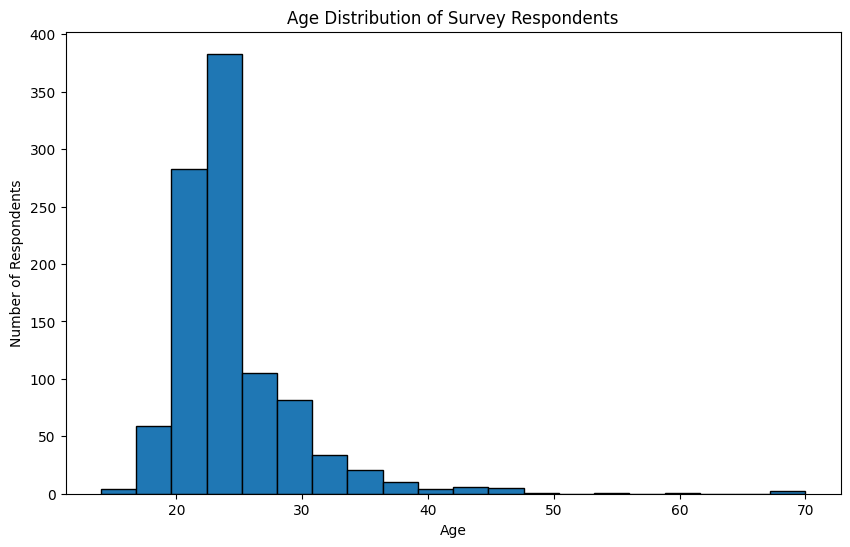

In [ ]:
average_age = df['age'].mean()

plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=20, edgecolor='k')
plt.title('Age Distribution of Survey Respondents')
plt.xlabel('Age')
plt.ylabel('Number of Respondents')
plt.show()

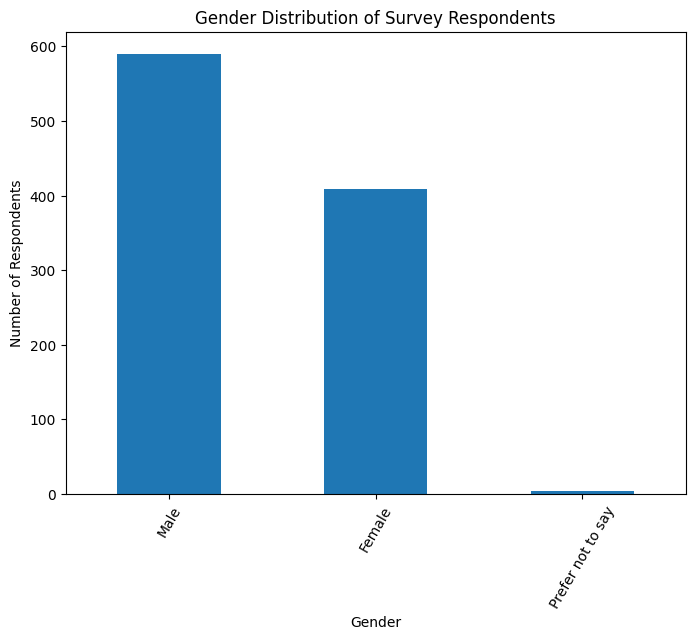

In [ ]:
gender_distribution = df['gender'].value_counts()

plt.figure(figsize=(8, 6))
gender_distribution.plot(kind='bar')
plt.title('Gender Distribution of Survey Respondents')
plt.xlabel('Gender')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=60)
plt.show()

In [ ]:
df['relationship_status'] = (
    df['relationship_status']
      .astype(str)
      .str.replace('\xa0', ' ', regex=False)   # remove non-breaking spaces
      .str.replace(r'\s+', ' ', regex=True)    # collapse weird spacing
      .str.strip()
      .replace(to_replace=r'^In a relationship\s*/\s*Married$', value='In a relationship', regex=True)
)



In [ ]:
df['relationship_status'].value_counts()


,count
relationship_status,
Single,715
In a relationship,244
Prefer not to say,44


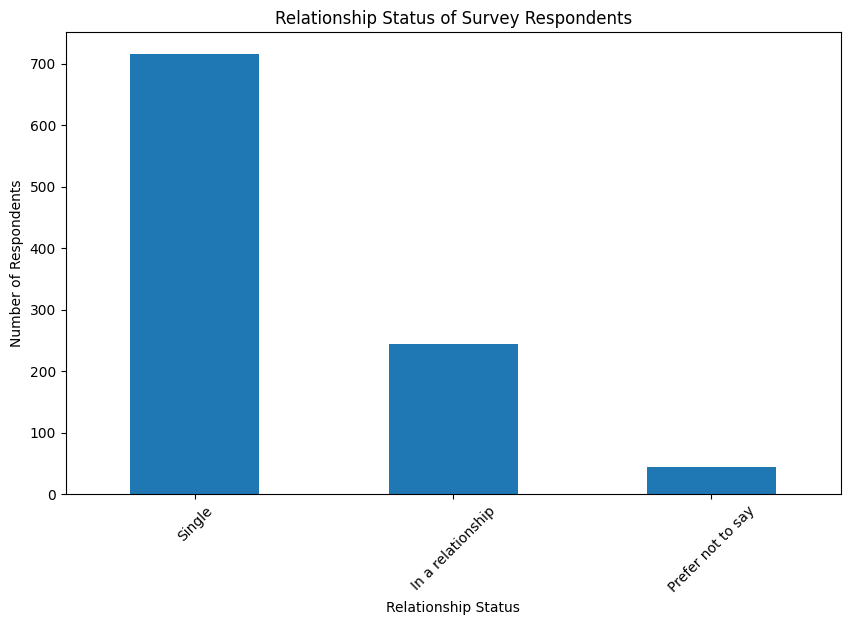

In [ ]:
relationship_statuses = df['relationship_status'].value_counts()

plt.figure(figsize=(10, 6))
relationship_statuses.plot(kind='bar')
plt.title('Relationship Status of Survey Respondents')
plt.xlabel('Relationship Status')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['occupation_status'] = (
    df['occupation_status']
    .astype(str)
    .str.strip()      # remove leading/trailing spaces
    .str.title()      # standardize casing
)


In [ ]:
df['occupation_status'].value_counts()

,count
occupation_status,
Student,713
Employee,173
Unemployed,42
Homemaker,41
Self-Employed / Freelancer,30
Banker,4


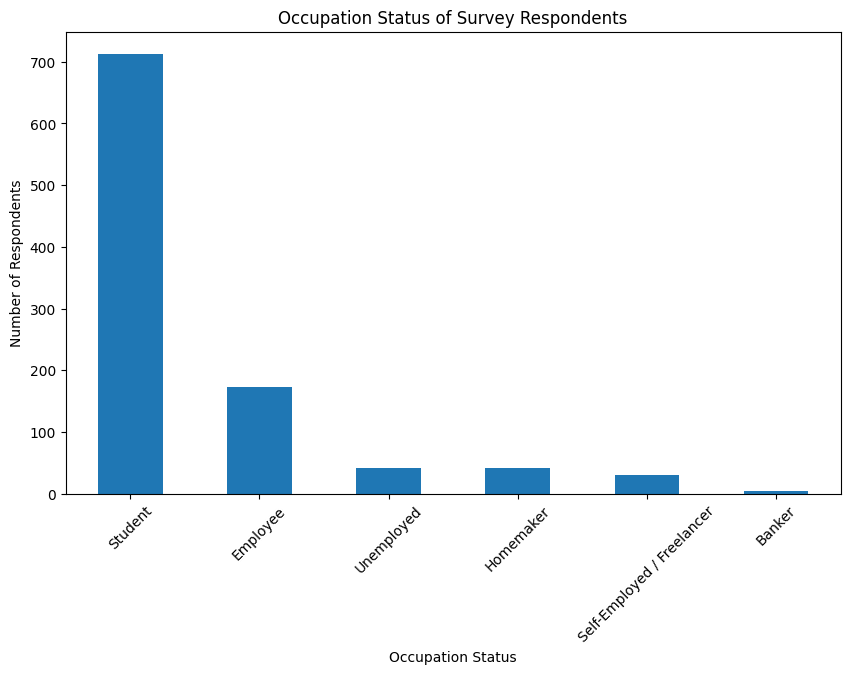

In [ ]:
occupation_statuses = df['occupation_status'].value_counts()

plt.figure(figsize=(10, 6))
occupation_statuses.plot(kind='bar')
plt.title('Occupation Status of Survey Respondents')
plt.xlabel('Occupation Status')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.show()

In [ ]:

unique_platforms = (
    df['platforms_used']
      .dropna()
      .astype(str)
      .str.lower()
      .str.replace('\u2019', "'", regex=False)   # curly apostrophe
      .str.replace('\xa0', ' ', regex=False)    # non-breaking space
      .str.replace(r'\s+', ' ', regex=True)
      .str.strip()
      .str.split(r'\s*[,;]\s*')                 # split comma OR semicolon
      .explode()
      .str.strip()
      .unique()
)

unique_platforms


array(['facebook', 'instagram', 'youtube', 'snapchat', 'linkedin',
       'tiktok', 'x (twitter)', 'reddit', 'whatsapp', 'microsoft team',
       '', 'wechat', 'netflix', 'telegram', 'chatgpt', 'capcut',
       "what's app", 'anime', "what's up", '24'], dtype=object)

In [ ]:

import pandas as pd

platform_counts = (
    df['platforms_used']
      .dropna()
      .astype(str)
      .str.lower()
      .str.replace('\u2019', "'", regex=False)     # curly ’ -> '
      .str.replace('\xa0', ' ', regex=False)       # non-breaking space
      .str.replace(r'\s+', ' ', regex=True)
      .str.strip()
      .str.split(r'\s*[,;]\s*')                    # split comma/semicolon
      .explode()
      .str.strip()
)

# ✅ normalize WhatsApp variants (regex)
platform_counts = platform_counts.replace({
    r"^what'?s\s*up$": "whatsapp",     # what's up / whats up
    r"^whats\s*app$": "whatsapp",      # whats app
    r"^whats\s*app\.?$": "whatsapp",   # whats app.
    r"^whats\s*up$": "whatsapp",       # whats up
    r"^whats?up$": "whatsapp",         # whatsup / whats up
}, regex=True)

platform_counts = platform_counts.replace('', pd.NA).dropna().value_counts()


In [ ]:
platform_clean_map = {
    "what's app": "whatsapp",
    "whats app": "whatsapp",
    "what's up": "whatsapp",
    "whats up": "whatsapp",
    "whatsup": "whatsapp",
}
cleaned_platforms = (
    df['platforms_used']
      .dropna()
      .astype(str)
      .str.lower()
      .str.replace('\u2019', "'", regex=False)   # curly apostrophe
      .str.replace('\xa0', ' ', regex=False)    # non-breaking space
      .str.replace(r'\s+', ' ', regex=True)
      .str.strip()
      .str.split(r'\s*[,;]\s*')
      .explode()
      .str.strip()
      .replace(platform_clean_map)
      .replace(['', '24'], pd.NA)               # remove junk values
      .dropna()
)
sorted(cleaned_platforms.unique())



['anime',
 'capcut',
 'chatgpt',
 'facebook',
 'instagram',
 'linkedin',
 'microsoft team',
 'netflix',
 'reddit',
 'snapchat',
 'telegram',
 'tiktok',
 'wechat',
 'whatsapp',
 'x (twitter)',
 'youtube']

In [ ]:
platform_counts = cleaned_platforms.value_counts()


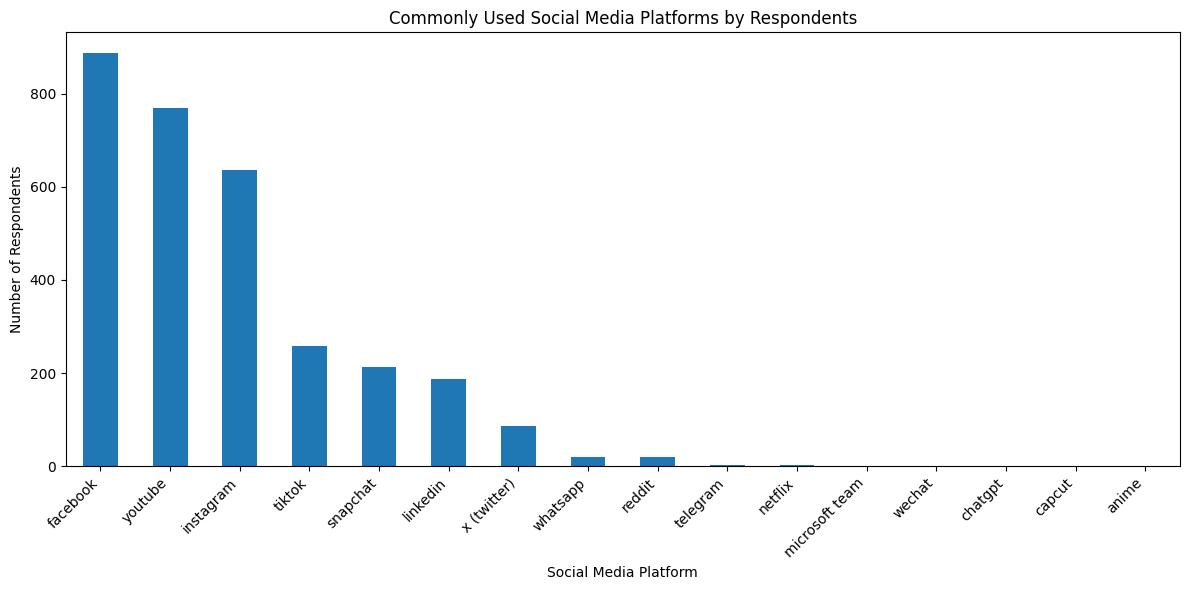

In [ ]:
plt.figure(figsize=(12, 6))
platform_counts.plot(kind='bar')
plt.title('Commonly Used Social Media Platforms by Respondents')
plt.xlabel('Social Media Platform')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


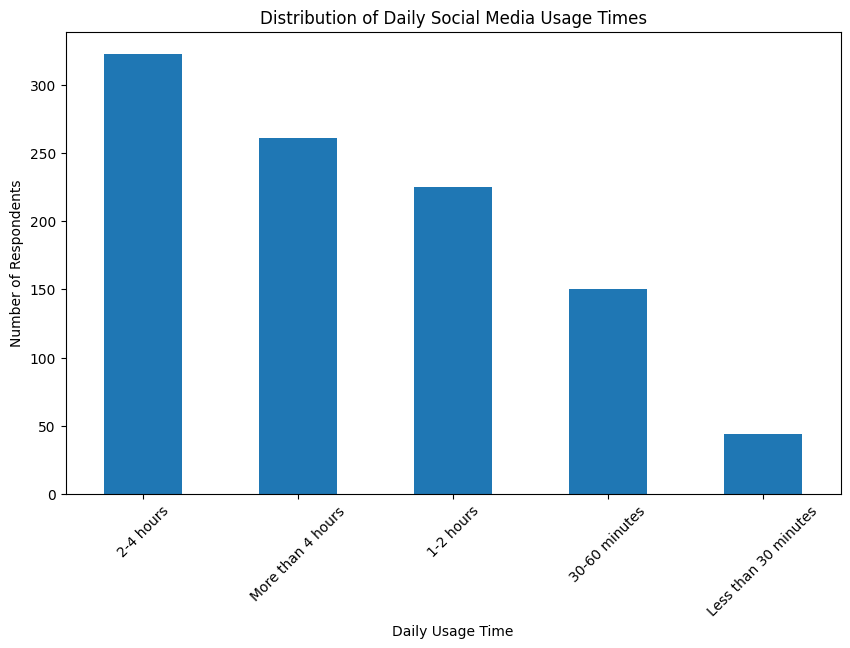

In [ ]:
daily_usage_distribution = df['daily_time_spent'].value_counts()

plt.figure(figsize=(10, 6))
daily_usage_distribution.plot(kind='bar')
plt.title('Distribution of Daily Social Media Usage Times')
plt.xlabel('Daily Usage Time')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['mindless_use_freq'].value_counts()

,count
mindless_use_freq,
Sometimes,450
Rarely,183
Often,175
Never,121
Always,74


In [ ]:
freq_map = {
    'Never': 1,
    'Rarely': 2,
    'Sometimes': 3,
    'Often': 4,
    'Always': 5
}

df['mindless_use_freq_num'] = (
    df['mindless_use_freq']
      .astype(str).str.strip().str.title()   # normalize: spaces + case
      .map(freq_map)
)

In [ ]:
df[df['mindless_use_freq_num'].isna()]['mindless_use_freq'].value_counts()


,count
mindless_use_freq,


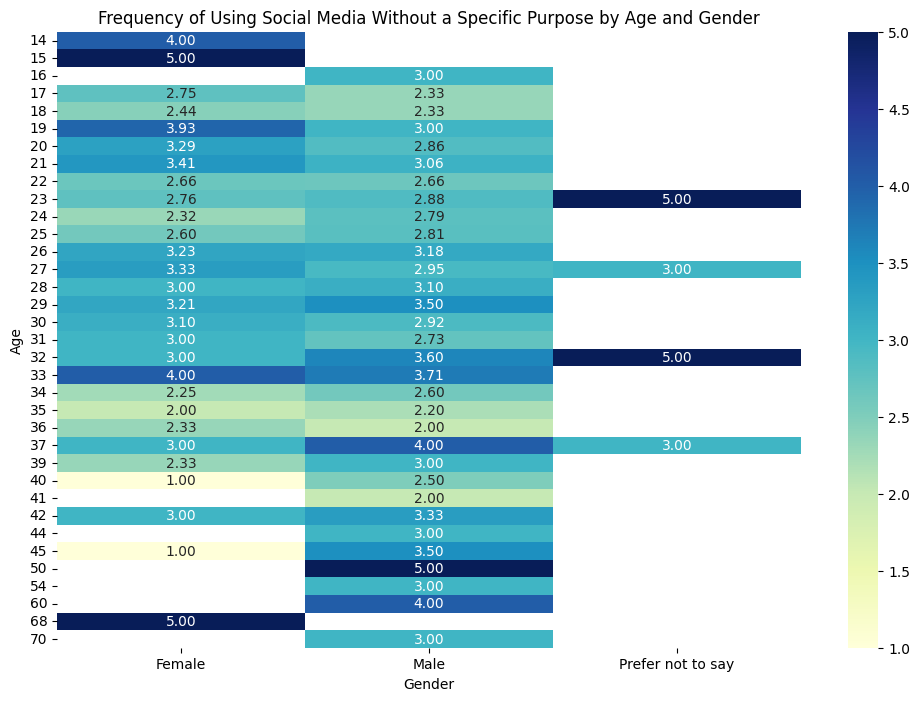

In [ ]:
freq_by_age_gender = (
    df.groupby(['age', 'gender'])['mindless_use_freq_num']
      .mean()
      .reset_index()
)

pivot_table = freq_by_age_gender.pivot_table(
    index='age', columns='gender', values='mindless_use_freq_num'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Frequency of Using Social Media Without a Specific Purpose by Age and Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()


In [ ]:
df["daily_time_spent"].value_counts()


,count
daily_time_spent,
2-4 hours,323
More than 4 hours,261
1-2 hours,225
30-60 minutes,150
Less than 30 minutes,44


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_852/3135430635.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['daily_time_spent'] = df['daily_time_spent'].str.extract('(\d+)')


Correlation between Time Spent on Social Media and Feelings of Restlessness: -0.17


<Figure size 1000x600 with 0 Axes>

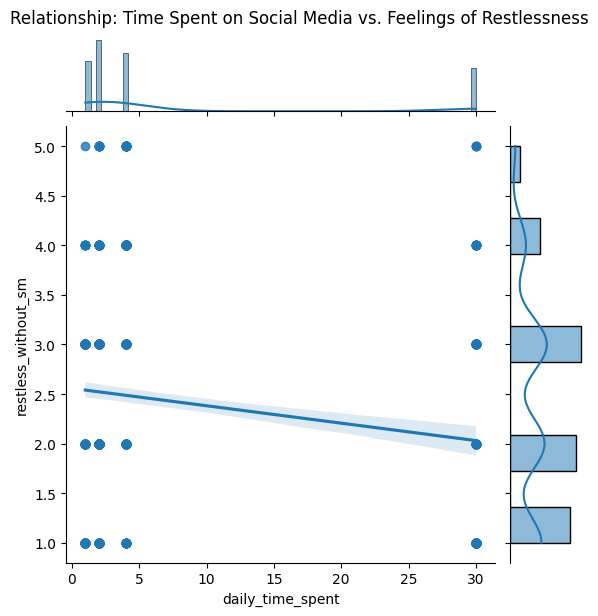

In [ ]:
df['daily_time_spent'] = df['daily_time_spent'].astype(str)
df['daily_time_spent'] = df['daily_time_spent'].str.extract('(\d+)')
df['daily_time_spent'] = pd.to_numeric(df['daily_time_spent'])
correlation = df['daily_time_spent'].corr(df['restless_without_sm'])

print(f"Correlation between Time Spent on Social Media and Feelings of Restlessness: {correlation:.2f}")


plt.figure(figsize=(10, 6))
sns.jointplot(x='daily_time_spent', y='restless_without_sm', data=df, kind='reg')
plt.suptitle('Relationship: Time Spent on Social Media vs. Feelings of Restlessness', y=1.02)
plt.show()


In [ ]:
df['distraction_impact']

,distraction_impact
0,2
1,5
2,5
3,2
4,1
...,...
1000,3
1001,3
1002,2
1003,2


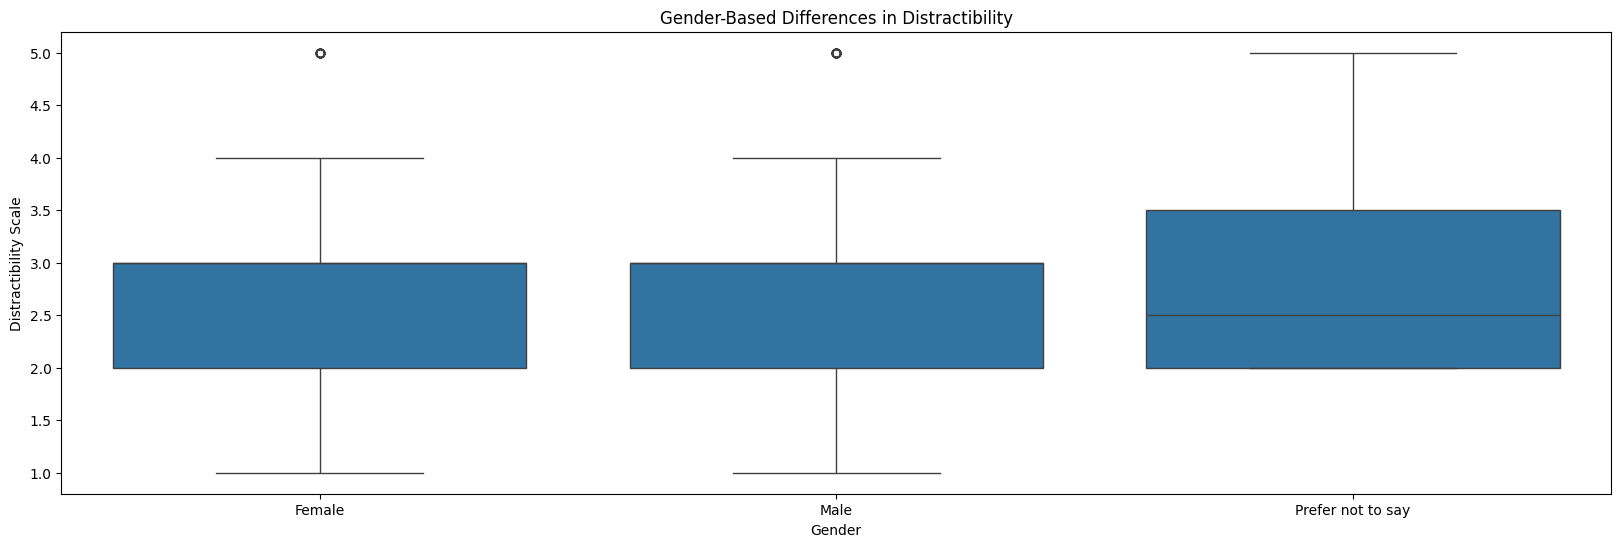

In [ ]:
plt.figure(figsize=(20, 6))
sns.boxplot(x='gender', y='distraction_impact', data=df)
plt.title('Gender-Based Differences in Distractibility')
plt.xlabel('Gender')
plt.ylabel('Distractibility Scale')
plt.show()



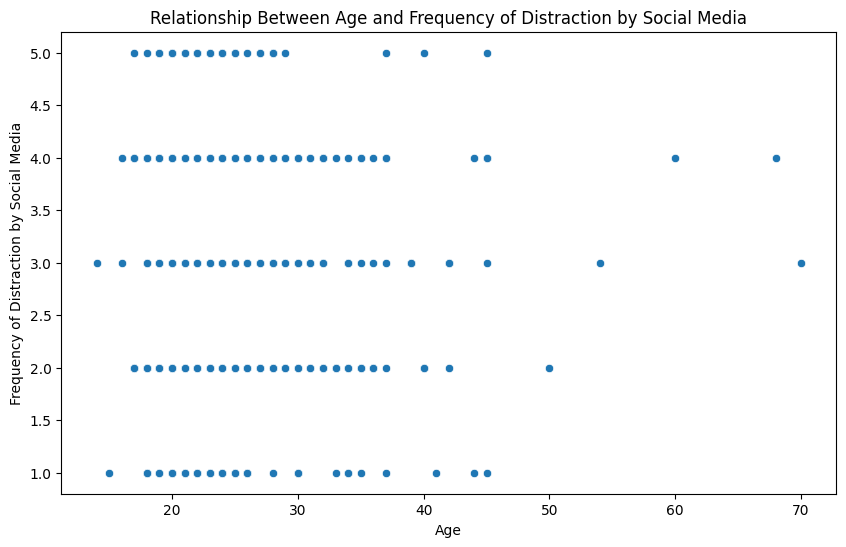

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='distraction_impact', data=df)
plt.title('Relationship Between Age and Frequency of Distraction by Social Media')
plt.xlabel('Age')
plt.ylabel('Frequency of Distraction by Social Media')
plt.show()

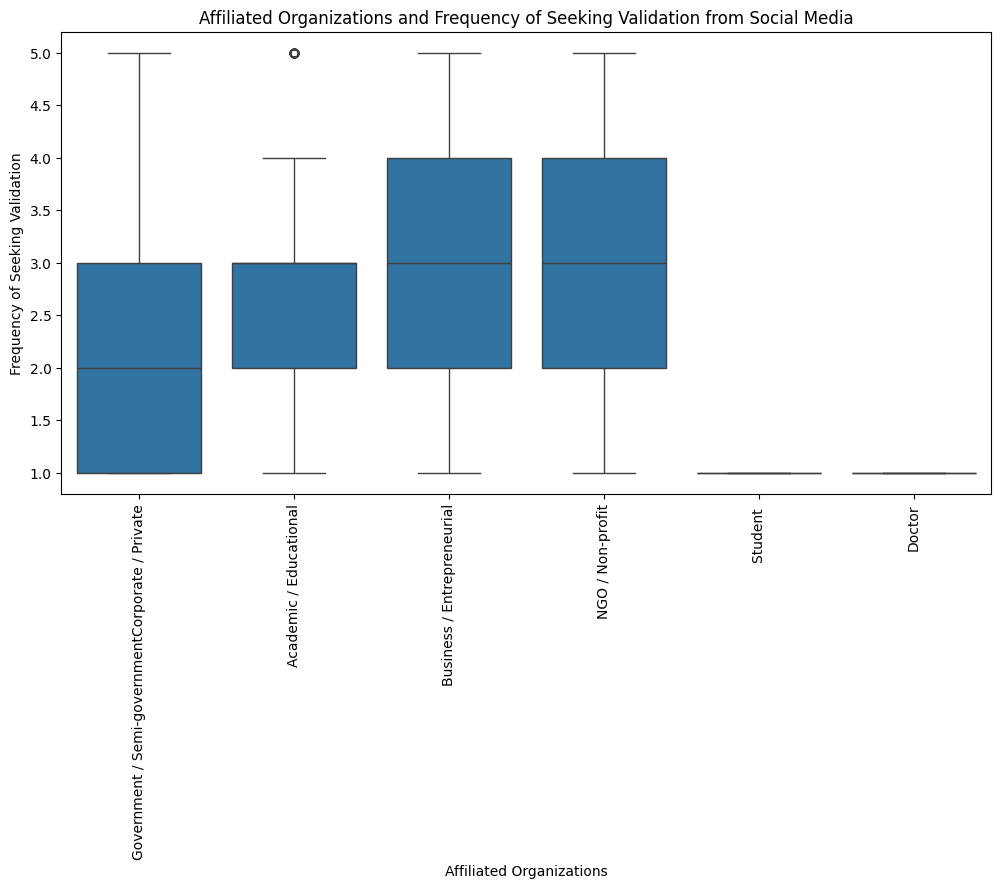

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='org_affiliation', y='validation_seeking_freq', data=df)
plt.title('Affiliated Organizations and Frequency of Seeking Validation from Social Media')
plt.xlabel('Affiliated Organizations')
plt.ylabel('Frequency of Seeking Validation')
plt.xticks(rotation=90)
plt.show()

In [ ]:
import pandas as pd

# Optional: standardize separators (comma/semicolon) and WhatsApp variants first
platforms_clean = (
    df['platforms_used']
      .fillna('')
      .astype(str)
      .str.lower()
      .str.replace('\u2019', "'", regex=False)
      .str.replace(r'\s*[,;]\s*', ', ', regex=True)  # unify separators
      .str.replace(r"what'?s?\s*(app|up)", "whatsapp", regex=True)
      .str.replace(r'\s+', ' ', regex=True)
      .str.strip()
)

platform_dummies = platforms_clean.str.get_dummies(sep=', ')

df_platform = pd.concat(
    [
        df[["age", "gender", "relationship_status", "occupation_status",
            "org_affiliation", "daily_time_spent",
            "mindless_use_freq", "distraction_when_busy_freq", "restless_without_sm",
            "distraction_impact", "concentration_difficulty_freq",
            "social_comparison_freq", "comparison_feelings",
            "validation_seeking_freq", "low_mood_freq", "interest_fluctuation_freq",
            "sleep_issues_freq"]],
        platform_dummies
    ],
    axis=1
)




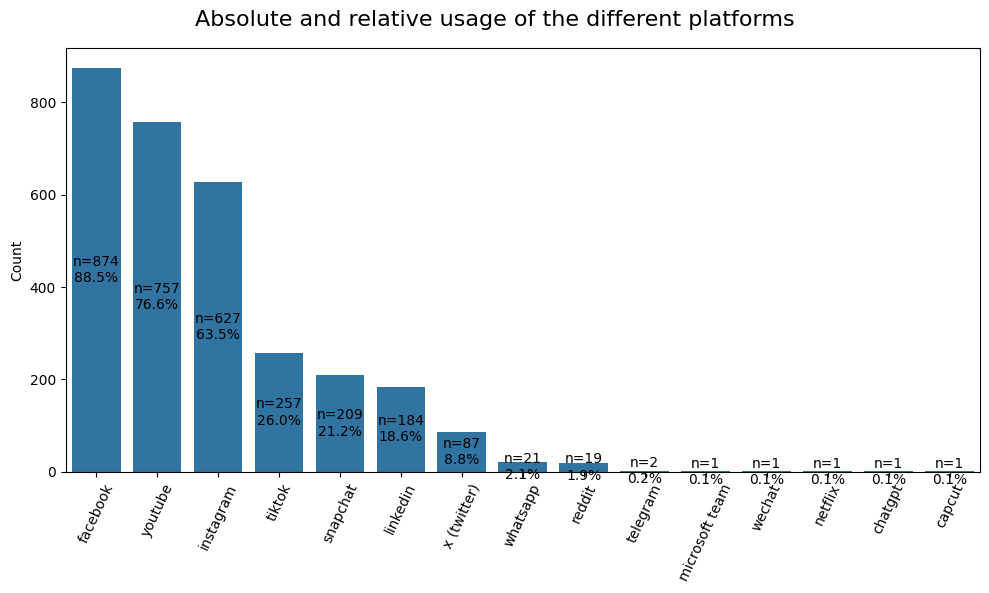

In [ ]:

df_yes = df[df['uses_social_media'].str.strip().str.lower() == 'yes'].copy()
maxval = df_yes.shape[0]   # denominator for percentage

# Clean + split into individual platforms
platform_series = (
    df_yes['platforms_used']
      .dropna()
      .astype(str)
      .str.lower()
      .str.replace('\u2019', "'", regex=False)
      .str.replace('\xa0', ' ', regex=False)
      .str.replace(r'\s+', ' ', regex=True)
      .str.strip()
      .str.split(r'\s*[,;]\s*')    # ✅ split by comma OR semicolon, any spaces
      .explode()
      .str.strip()
)

# Normalize WhatsApp variants + remove junk
platform_series = platform_series.replace({
    r"^what'?s?\s*(app|up)$": "whatsapp",
    r"^whats\s*(app|up)$": "whatsapp",
    r"^whats?up$": "whatsapp",
    "": pd.NA,
    "24": pd.NA
}, regex=True).dropna()

# Count platforms (each platform counted once per person selection)
platform_counts = platform_series.value_counts()

# (Optional) choose only top N to keep chart readable
top_n = 15
platform_counts = platform_counts.head(top_n)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=platform_counts.index, y=platform_counts.values, ax=ax)

fig.suptitle("Absolute and relative usage of the different platforms", fontsize=16)
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=65)

# Annotate counts and percentages
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()
    x = p.get_x()
    xy = (x + w / 2., h / 2)
    percent = (h / maxval) * 100
    ax.annotate(f'n={h:0.0f}\n{percent:0.1f}%', xy=xy, ha='center', va='center')

plt.tight_layout()
plt.show()


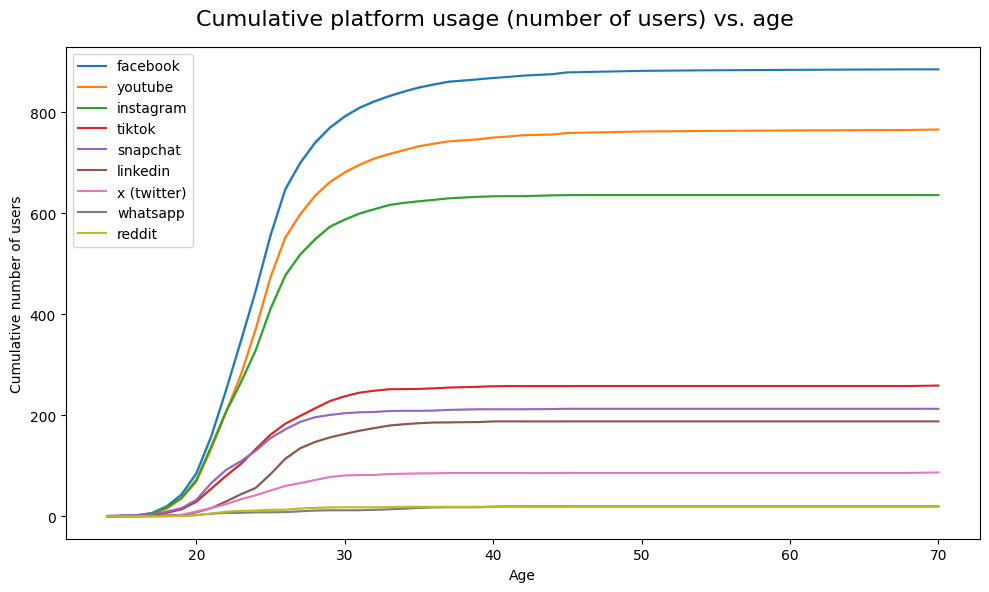

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Clean platforms_used into a single standardized string per row
platforms_clean = (
    df['platforms_used']
      .fillna('')
      .astype(str)
      .str.lower()
      .str.replace('\u2019', "'", regex=False)   # curly apostrophe
      .str.replace('\xa0', ' ', regex=False)    # non-breaking space
      .str.replace(r'\s+', ' ', regex=True)
      .str.strip()
      .str.replace(r'\s*[,;]\s*', ', ', regex=True)  # unify separators to ", "
)

# 2) Normalize WhatsApp variants (THIS fixes your cumulative names)
platforms_clean = platforms_clean.replace(
    to_replace=r"\bwhat'?s?\s*(app|up)\b|\bwhats\s*(app|up)\b|\bwhats?up\b",
    value="whatsapp",
    regex=True
)

# 3) Remove junk tokens like empty and "24"
platforms_clean = platforms_clean.replace(
    to_replace=r'(^|,\s*)(24)($|,\s*)',
    value=', ',
    regex=True
).str.replace(r'(^,\s*|,\s*$)', '', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()

# 4) Create one-hot encoded platform columns from CLEANED string
platform_dummies = platforms_clean.str.get_dummies(sep=', ')

# If an empty column appears, drop it safely
if '' in platform_dummies.columns:
    platform_dummies = platform_dummies.drop(columns=[''])

# 5) Build df_platform (base columns + dummies)
base_cols = [
    "age", "gender", "relationship_status", "occupation_status",
    "org_affiliation", "daily_time_spent",
    "mindless_use_freq", "distraction_when_busy_freq", "restless_without_sm",
    "distraction_impact", "concentration_difficulty_freq",
    "social_comparison_freq", "comparison_feelings",
    "validation_seeking_freq", "low_mood_freq", "interest_fluctuation_freq",
    "sleep_issues_freq"
]

df_platform = pd.concat([df[base_cols].copy(), platform_dummies], axis=1)

# 6) Make age numeric + sort
df_platform['age'] = pd.to_numeric(df_platform['age'], errors='coerce')
df_platform = df_platform.dropna(subset=['age'])
df_platform['age'] = df_platform['age'].astype(int)
df_sorted = df_platform.sort_values('age')

# 7) Choose platform columns (all dummy columns)
platform_list = platform_dummies.columns.tolist()

# OPTIONAL: top 7 platforms only (cleanest plot)
top7 = df_sorted[platform_list].sum().sort_values(ascending=False).head(9).index.tolist()

# 8) Plot cumulative usage vs age (WhatsApp will be only ONE column now)
fig, ax = plt.subplots(figsize=(10,6))

for platform in top7:
    sns.lineplot(
        x=df_sorted['age'],
        y=df_sorted[platform].fillna(0).cumsum(),
        ax=ax,
        label=platform
    )

fig.suptitle("Cumulative platform usage (number of users) vs. age", fontsize=16)
ax.set_xlabel("Age")
ax.set_ylabel("Cumulative number of users")
plt.tight_layout()
plt.show()


In [ ]:
df_20 = df_platform.query("age <= 20")
df_21_30 = df_platform.query("age > 20 & age <=30")
df_31_40 = df_platform.query("age > 30 & age <=40")
df_40 = df_platform.query("age > 40")
print(f"Age below 20: n={len(df_20)}")
print(f"Age 21 to 30: n={len(df_21_30)}")
print(f"Age 31 to 40: n={len(df_31_40)}")
print(f"Age above 40: n={len(df_40)}")

Age below 20: n=137
Age 21 to 30: n=779
Age 31 to 40: n=68
Age above 40: n=17


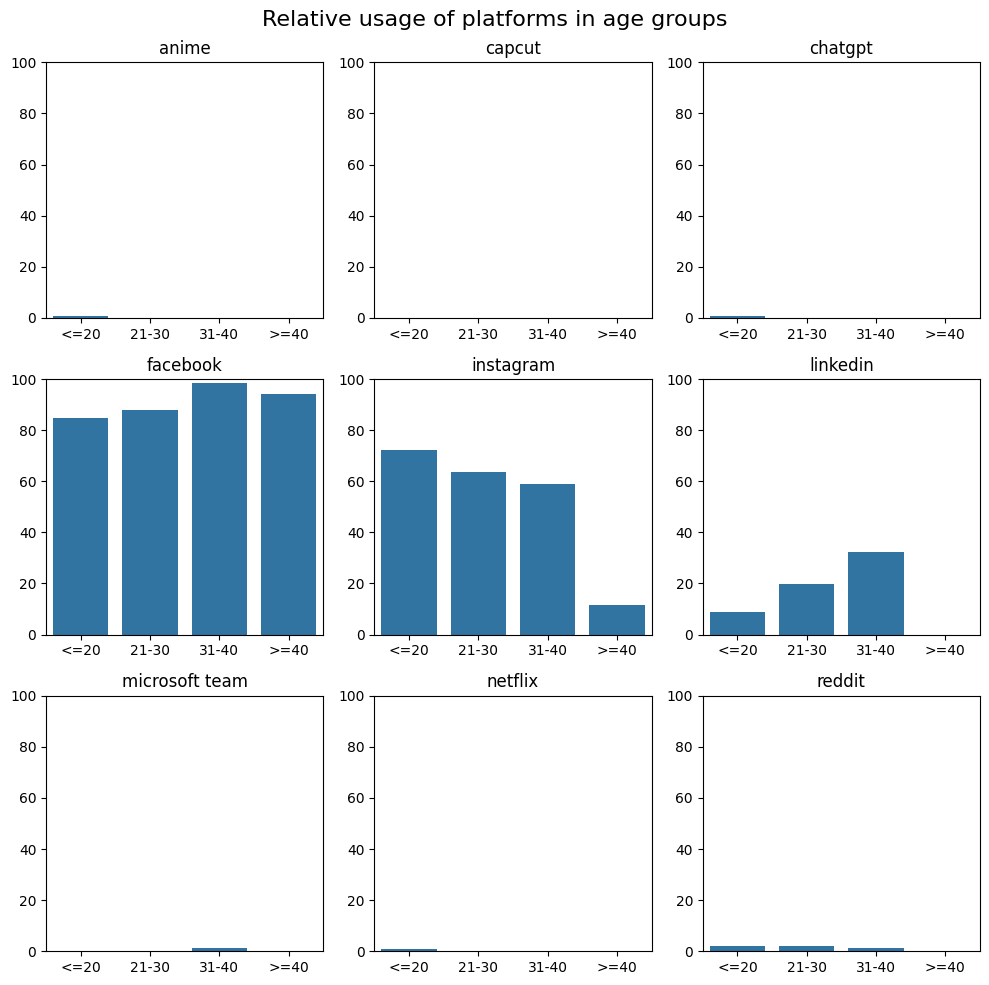

In [ ]:
fig, axes = plt.subplots(3,3, figsize=(10,10))
axes = axes.flatten()

for (ax, platform) in zip(axes, platform_list):
    x_list = ["<=20","21-30","31-40",">=40"]
    percent20 = df_20[platform].sum()/len(df_20)*100
    percent2130 = df_21_30[platform].sum()/len(df_21_30)*100
    percent3140 = df_31_40[platform].sum()/len(df_31_40)*100
    percent40 = df_40[platform].sum()/len(df_40)*100
    y_list = [percent20, percent2130, percent3140, percent40]
    sns.barplot(x=x_list, y=y_list, ax=ax)
    ax.set_ylim(0,100)
    ax.set_title(platform)
fig.suptitle("Relative usage of platforms in age groups", fontsize=16)
plt.tight_layout()

In [ ]:
df_platform.columns

Index(['age', 'gender', 'relationship_status', 'occupation_status',
       'org_affiliation', 'daily_time_spent', 'mindless_use_freq',
       'distraction_when_busy_freq', 'restless_without_sm',
       'distraction_impact', 'concentration_difficulty_freq',
       'social_comparison_freq', 'comparison_feelings',
       'validation_seeking_freq', 'low_mood_freq', 'interest_fluctuation_freq',
       'sleep_issues_freq', 'anime', 'capcut', 'chatgpt', 'facebook',
       'instagram', 'linkedin', 'microsoft team', 'netflix', 'reddit',
       'snapchat', 'telegram', 'tiktok', 'wechat', 'whatsapp', 'x (twitter)',
       'youtube'],
      dtype='object')

In [ ]:
df_platform['concentration_difficulty_freq']

,concentration_difficulty_freq
0,Rarely
1,Always
2,Always
3,Sometimes
4,Sometimes
...,...
1000,Sometimes
1001,Sometimes
1002,Never
1003,Rarely


In [ ]:
df_platform.dtypes

,0
age,int64
gender,object
relationship_status,object
occupation_status,object
org_affiliation,object
daily_time_spent,int64
mindless_use_freq,object
distraction_when_busy_freq,object
restless_without_sm,int64
distraction_impact,int64


In [ ]:
df_platform['mindless_use_freq'].value_counts()

,count
mindless_use_freq,
Sometimes,449
Rarely,183
Often,174
Never,121
Always,74


In [ ]:
df_platform['distraction_when_busy_freq'].value_counts()

,count
distraction_when_busy_freq,
Sometimes,441
Rarely,194
Often,191
Never,103
Always,72


In [ ]:
df_platform['concentration_difficulty_freq'].value_counts()

,count
concentration_difficulty_freq,
Sometimes,467
Rarely,205
Often,141
Never,137
Always,51


In [ ]:
df_platform['comparison_feelings'].value_counts()

,count
comparison_feelings,
No change,425
slightly worse,235
Slightly better,176
Much worse,113
Much better,52


In [ ]:
freq_cols = [
    "mindless_use_freq",
    "distraction_when_busy_freq",
    "concentration_difficulty_freq"

]

for col in freq_cols:
    df_platform[col] = (
        df_platform[col]
        .astype(str)      # ensure string
        .str.strip()      # remove spaces
        .str.title()      # normalize case
    )


In [ ]:
freq_map = {
    "Never": 1,
    "Rarely": 2,
    "Sometimes": 3,
    "Often": 4,
    "Always": 5
}

for col in freq_cols:
    df_platform[col] = df_platform[col].map(freq_map)



In [ ]:
comparison_map = {
    "Much Better": 1,
    "Slightly Better": 2,
    "No Change": 3,
    "Slightly Worse": 4,
    "Much Worse": 5
}


In [ ]:
df_platform["comparison_feelings"] = (
    df_platform["comparison_feelings"]
    .astype(str)
    .str.strip()
    .str.title()
)

df_platform["comparison_feelings"] = (
    df_platform["comparison_feelings"]
    .map(comparison_map)
    .fillna(0)
    .astype(int)
)


In [ ]:
df_platform["platform_sum"] = 0
for platform in platform_list:
    df_platform["platform_sum"] = df_platform["platform_sum"] + df_platform[platform].fillna(0).astype(int)

df_platform["impact_sum"] = 0
df_platform["impact_sum"] = df_platform["mindless_use_freq"] + df_platform["distraction_when_busy_freq"] + df_platform["restless_without_sm"] + df_platform["distraction_impact"]  + df_platform["concentration_difficulty_freq"] + df_platform["social_comparison_freq"] + df_platform["comparison_feelings"] + df_platform["validation_seeking_freq"] + df_platform["low_mood_freq"] + df_platform["interest_fluctuation_freq"] + df_platform["sleep_issues_freq"]

In [ ]:
df_platform['comparison_feelings'].value_counts()

,count
comparison_feelings,
3,425
4,235
2,176
5,113
1,52


In [ ]:
df_platform.head()

,age,gender,relationship_status,occupation_status,org_affiliation,daily_time_spent,mindless_use_freq,distraction_when_busy_freq,restless_without_sm,distraction_impact,...,reddit,snapchat,telegram,tiktok,wechat,whatsapp,x (twitter),youtube,platform_sum,impact_sum
0,27,Female,Single,Employee,Government / Semi-governmentCorporate / Private,4,4,2,2,2,...,0,0,0,0,0,0,0,1,3,29.0
1,25,Male,In a relationship,Student,Academic / Educational,4,4,5,4,5,...,0,0,0,0,0,0,0,1,3,44.0
2,23,Female,Single,Student,Academic / Educational,4,5,5,5,5,...,0,1,0,0,0,0,0,1,5,45.0
3,23,Female,Single,Student,Academic / Educational,1,3,4,2,2,...,0,0,0,0,0,0,0,1,3,27.0
4,20,Female,Single,Student,Academic / Educational,4,3,3,1,1,...,0,1,0,1,0,0,0,1,5,23.0


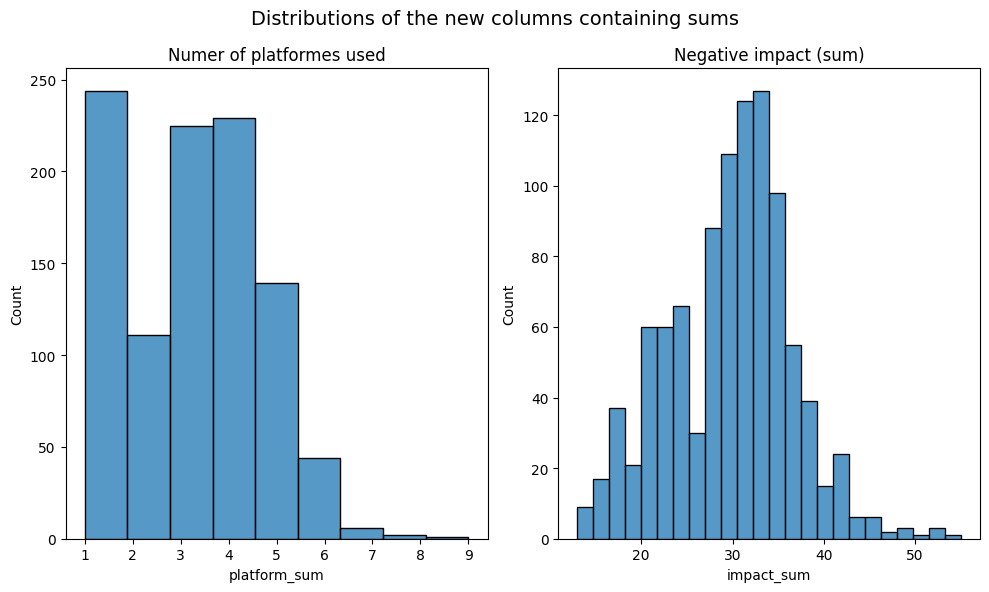

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,6))
sns.histplot(data = df_platform, x="platform_sum", ax=ax[0], bins=9)
sns.histplot(data = df_platform, x="impact_sum", ax=ax[1])
fig.suptitle("Distributions of the new columns containing sums", fontsize=14)
ax[0].set_title("Numer of platformes used")
ax[1].set_title("Negative impact (sum)")
plt.tight_layout()

In [ ]:
df_platform['impact_sum']

,impact_sum
0,29.0
1,44.0
2,45.0
3,27.0
4,23.0
...,...
1000,33.0
1001,33.0
1002,26.0
1003,37.0


<Axes: xlabel='platform_sum', ylabel='impact_sum'>

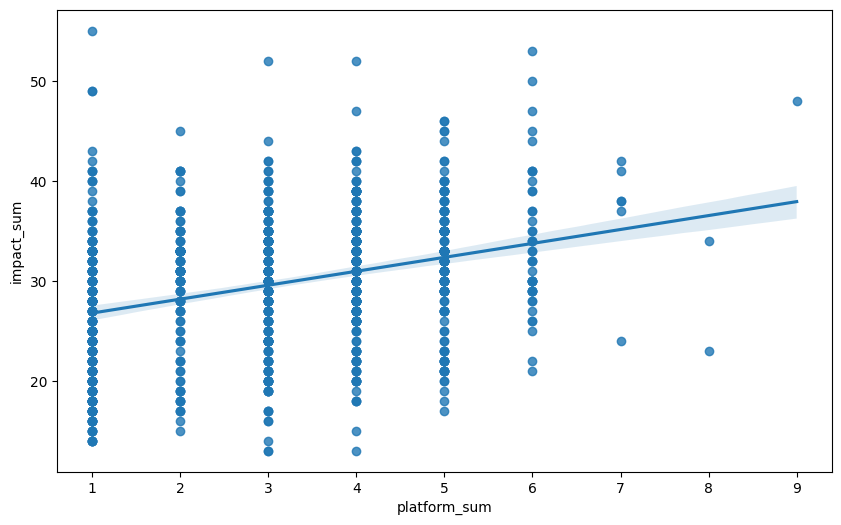

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(x=df_platform.platform_sum, y=df_platform.impact_sum, ax=ax)

<Axes: xlabel='age', ylabel='impact_sum'>

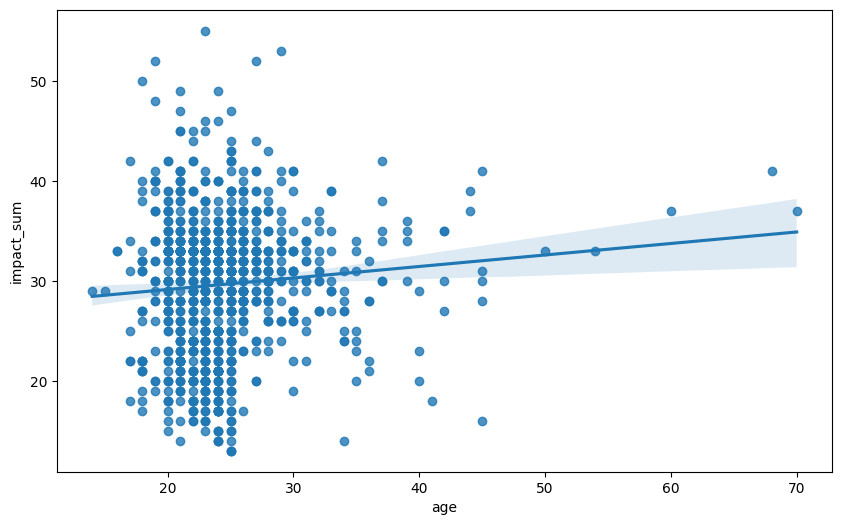

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(x=df_platform.age, y=df_platform.impact_sum, ax=ax)

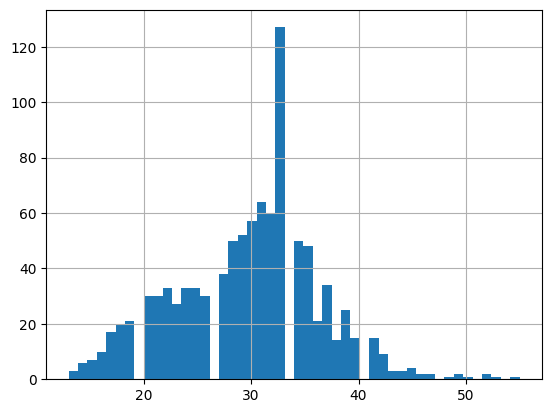

In [ ]:
df_platform.impact_sum.hist(bins=48);

In [ ]:
df_platform["impact_sum"].describe(percentiles=[0.25, 0.5, 0.75, 0.9])


,impact_sum
count,1001.000000
mean,29.648352
std,6.790745
min,13.000000
25%,25.000000
50%,31.000000
75%,34.000000
90%,37.000000
max,55.000000


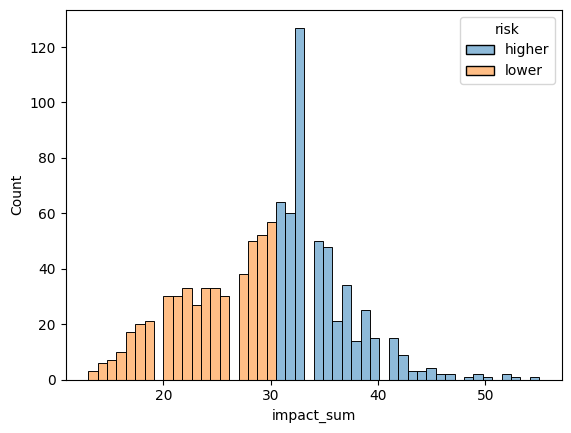

In [ ]:
df_platform["risk"] = "lower"
df_platform.loc[df_platform[df_platform.impact_sum >= 31].index, "risk"] = "higher"
df_platform.risk = df_platform.risk.astype("category")
sns.histplot(x=df_platform.impact_sum, bins=48, hue=df_platform.risk);


In [ ]:
impact_cols = [
    "mindless_use_freq",
    "distraction_when_busy_freq",
    "restless_without_sm",
    "distraction_impact",
    "concentration_difficulty_freq",
    "social_comparison_freq",
    "comparison_feelings",
    "validation_seeking_freq",
    "low_mood_freq",
    "interest_fluctuation_freq",
    "sleep_issues_freq",
]



In [ ]:
impact_pct = df_platform[impact_cols].div(df_platform["impact_sum"], axis=0) * 100


In [ ]:
avg_contribution = df_platform[impact_cols].mean()
avg_contribution_pct = (avg_contribution / 5) * 100



In [ ]:
avg_contribution_pct

,0
mindless_use_freq,57.942058
distraction_when_busy_freq,58.701299
restless_without_sm,48.471528
distraction_impact,51.868132
concentration_difficulty_freq,55.284715
social_comparison_freq,44.715285
comparison_feelings,63.616384
validation_seeking_freq,49.410589
low_mood_freq,53.046953
interest_fluctuation_freq,54.665335


In [ ]:
df_platform['impact_sum'].max()

55.0

In [ ]:
df_platform.index[df_platform["impact_sum"] == df_platform["impact_sum"].max()]


Index([355], dtype='int64')

In [ ]:
df_platform.loc[df_platform["impact_sum"].idxmax()]


,355
age,23
gender,Prefer not to say
relationship_status,In a relationship
occupation_status,Unemployed
org_affiliation,Academic / Educational
daily_time_spent,4
mindless_use_freq,5
distraction_when_busy_freq,5
restless_without_sm,5
distraction_impact,5


In [ ]:
df['top_distraction_sources'].value_counts().head(20)

,count
top_distraction_sources,
Endless scrolling / news feed,126
Messaging / chats,113
Notifications;Endless scrolling / news feed;Messaging / chats,56
Notifications;Endless scrolling / news feed;Messaging / chats;Trending news or updates,52
Notifications,52
Endless scrolling / news feed;Messaging / chats,40
Notifications;Endless scrolling / news feed;Messaging / chats;Trending news or updates;Entertainment / humorous content,40
Notifications;Endless scrolling / news feed;Messaging / chats;Entertainment / humorous content,37
Notifications;Endless scrolling / news feed;Messaging / chats;Trending news or updates;Comparing yourself with others;Entertainment / humorous content,37


In [ ]:

unique_distraction = (
    df['top_distraction_sources']
      .dropna()
      .astype(str)
      .str.lower()
      .str.replace('\u2019', "'", regex=False)   # curly apostrophe
      .str.replace('\xa0', ' ', regex=False)    # non-breaking space
      .str.replace(r'\s+', ' ', regex=True)
      .str.strip()
      .str.split(r'\s*[,;]\s*')                 # split comma OR semicolon
      .explode()
      .str.strip()
      .unique()
)

unique_distraction

array(['endless scrolling / news feed', 'messaging / chats',
       'notifications', 'trending news or updates',
       'comparing yourself with others',
       'entertainment / humorous content', 'none of these'], dtype=object)

In [ ]:
distraction_counts = (
    df['top_distraction_sources']
      .dropna()
      .astype(str)
      .str.lower()
      .str.replace('\u2019', "'", regex=False)     # curly ’ -> '
      .str.replace('\xa0', ' ', regex=False)       # non-breaking space
      .str.replace(r'\s+', ' ', regex=True)
      .str.strip()
      .str.split(r'\s*[,;]\s*')                    # split comma/semicolon
      .explode()
      .str.strip()
)

In [ ]:
sorted(distraction_counts.unique())

['comparing yourself with others',
 'endless scrolling / news feed',
 'entertainment / humorous content',
 'messaging / chats',
 'none of these',
 'notifications',
 'trending news or updates']

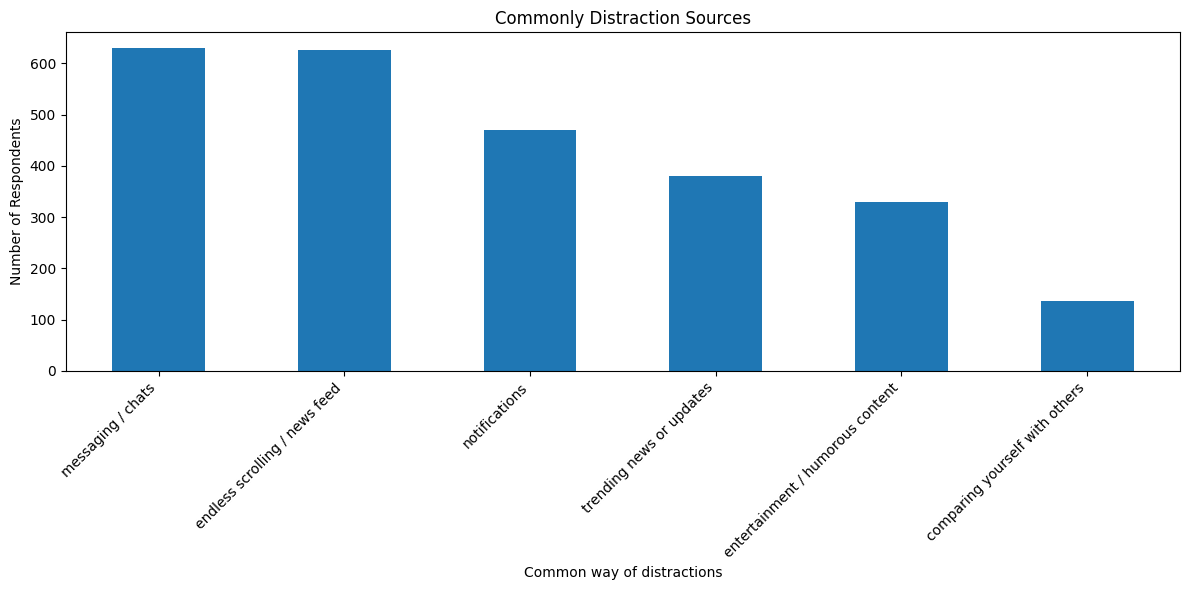

In [ ]:
distraction_counts1 = distraction_counts.value_counts().head(6)

plt.figure(figsize=(12, 6))
distraction_counts1.plot(kind='bar')
plt.title('Commonly Distraction Sources')
plt.xlabel('Common way of distractions')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_platform.columns

Index(['age', 'gender', 'relationship_status', 'occupation_status',
       'org_affiliation', 'daily_time_spent', 'mindless_use_freq',
       'distraction_when_busy_freq', 'restless_without_sm',
       'distraction_impact', 'concentration_difficulty_freq',
       'social_comparison_freq', 'comparison_feelings',
       'validation_seeking_freq', 'low_mood_freq', 'interest_fluctuation_freq',
       'sleep_issues_freq', 'anime', 'capcut', 'chatgpt', 'facebook',
       'instagram', 'linkedin', 'microsoft team', 'netflix', 'reddit',
       'snapchat', 'telegram', 'tiktok', 'wechat', 'whatsapp', 'x (twitter)',
       'youtube', 'platform_sum', 'impact_sum', 'risk'],
      dtype='object')

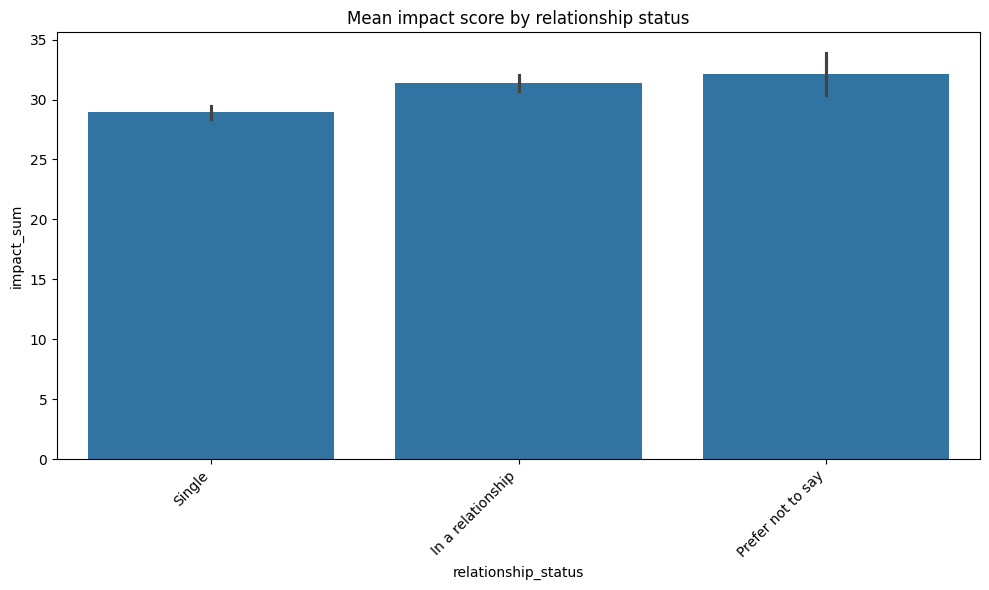

In [ ]:
import numpy as np

plt.figure(figsize=(10,6))
sns.barplot(
    x="relationship_status",
    y="impact_sum",
    data=df_platform,
    estimator=np.mean,
    errorbar="ci"  # confidence interval
)
plt.xticks(rotation=45, ha="right")
plt.title("Mean impact score by relationship status")
plt.tight_layout()
plt.show()


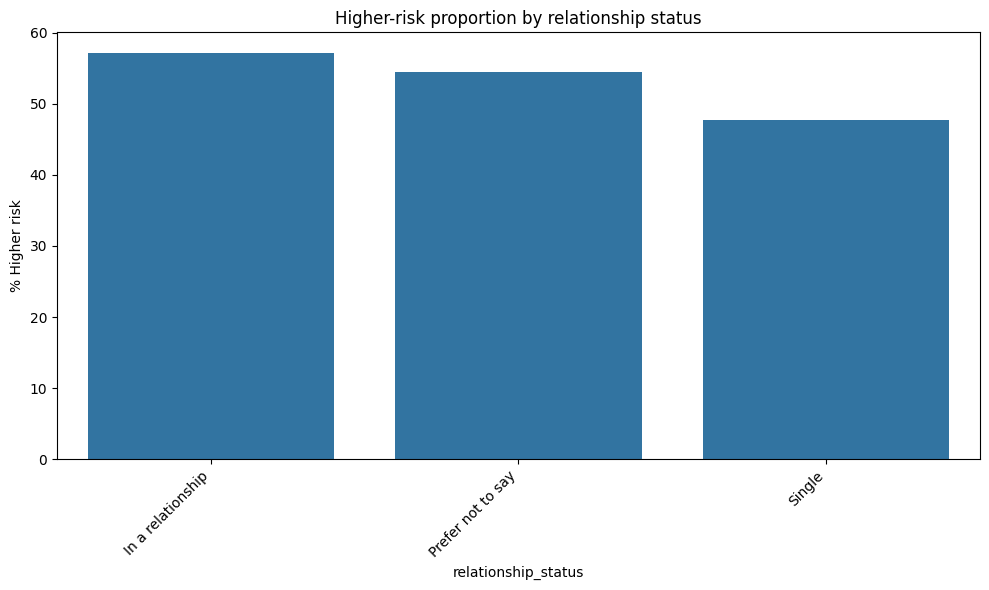

In [ ]:
risk_pct = (
    df_platform.groupby("relationship_status")["risk"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=risk_pct[risk_pct["risk"]=="higher"],
            x="relationship_status", y="percent")
plt.xticks(rotation=45, ha="right")
plt.ylabel("% Higher risk")
plt.title("Higher-risk proportion by relationship status")
plt.tight_layout()
plt.show()


In [ ]:
df_platform.shape

(1001, 36)

In [ ]:
# Convert age to numeric (same rule)
df["age_num"] = pd.to_numeric(df["age"], errors="coerce")

# Drop rows where age is missing/invalid
df = df.dropna(subset=["age_num"]).copy()

# Make age integer if you want
df["age"] = df["age_num"].astype(int)

# Remove helper column (optional)
df.drop(columns=["age_num"], inplace=True)

# Reset index for neatness (optional)
df.reset_index(drop=True, inplace=True)

df.shape



(1001, 23)

In [ ]:
df_platform["daily_productivity"] = df["daily_productivity"].values


In [ ]:
df_platform.columns

Index(['age', 'gender', 'relationship_status', 'occupation_status',
       'org_affiliation', 'daily_time_spent', 'mindless_use_freq',
       'distraction_when_busy_freq', 'restless_without_sm',
       'distraction_impact', 'concentration_difficulty_freq',
       'social_comparison_freq', 'comparison_feelings',
       'validation_seeking_freq', 'low_mood_freq', 'interest_fluctuation_freq',
       'sleep_issues_freq', 'anime', 'capcut', 'chatgpt', 'facebook',
       'instagram', 'linkedin', 'microsoft team', 'netflix', 'reddit',
       'snapchat', 'telegram', 'tiktok', 'wechat', 'whatsapp', 'x (twitter)',
       'youtube', 'platform_sum', 'impact_sum', 'risk', 'daily_productivity'],
      dtype='object')

In [ ]:
df_platform.groupby("daily_productivity")["impact_sum"].mean()


,impact_sum
daily_productivity,
1,23.546584
2,28.973262
3,31.993182
4,30.356322
5,28.461538


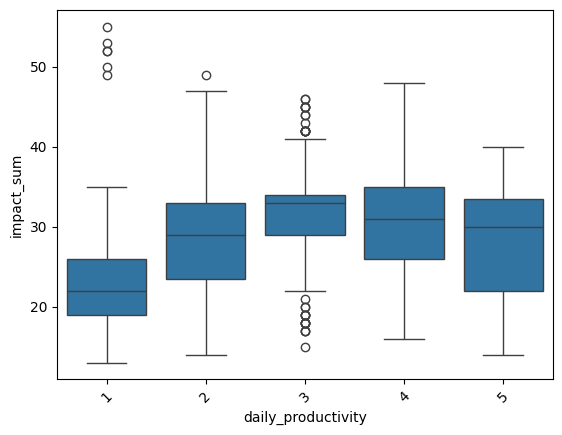

In [ ]:
sns.boxplot(x="daily_productivity", y="impact_sum", data=df_platform)
plt.xticks(rotation=45)
plt.show()


In [ ]:
df_platform["sm_negative_impact_freq"] = df["sm_negative_impact_freq"].values


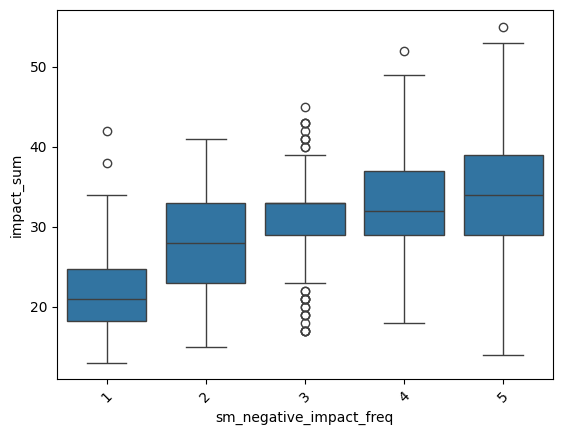

In [ ]:
sns.boxplot(
    x="sm_negative_impact_freq",
    y="impact_sum",
    data=df_platform
)
plt.xticks(rotation=45)
plt.show()


In [ ]:
df_platform.groupby("relationship_status")["impact_sum"].mean().sort_values()


,impact_sum
relationship_status,
Single,28.920168
In a relationship,31.341564
Prefer not to say,32.113636


In [ ]:
pd.crosstab(df_platform["relationship_status"], df_platform["risk"], normalize="index") * 100


risk,higher,lower
relationship_status,,
In a relationship,57.201646,42.798354
Prefer not to say,54.545455,45.454545
Single,47.759104,52.240896


In [ ]:
df_platform.groupby("occupation_status")["impact_sum"].mean().sort_values()


,impact_sum
occupation_status,
Student,29.135021
Employee,29.716763
Self-Employed / Freelancer,30.533333
Homemaker,32.536585
Banker,33.250000
Unemployed,34.261905


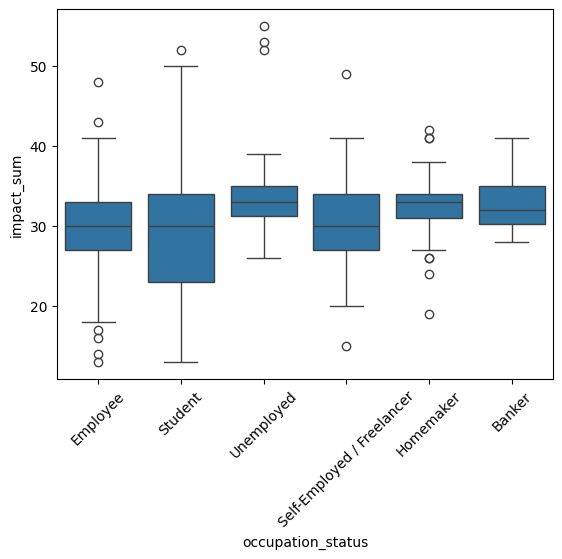

In [ ]:
sns.boxplot(x="occupation_status", y="impact_sum", data=df_platform)
plt.xticks(rotation=45)
plt.show()


In [ ]:
df_platform.groupby("org_affiliation")["impact_sum"].mean().sort_values()


,impact_sum
org_affiliation,
Doctor,19.000000
Government / Semi-governmentCorporate / Private,26.335079
Student,27.000000
Academic / Educational,30.170767
Business / Entrepreneurial,32.071429
NGO / Non-profit,32.121212


In [ ]:
df.groupby("uses_social_media")["restless_without_sm"].mean()


,restless_without_sm
uses_social_media,
No,1.800000
Yes,2.433063


In [ ]:
df_platform[["daily_time_spent","platform_sum","impact_sum"]].corr()



,daily_time_spent,platform_sum,impact_sum
daily_time_spent,1.000000,-0.406310,-0.218797
platform_sum,-0.406310,1.000000,0.320681
impact_sum,-0.218797,0.320681,1.000000


In [ ]:


impact_cols = [
    "mindless_use_freq","distraction_when_busy_freq","restless_without_sm",
    "distraction_impact","concentration_difficulty_freq","social_comparison_freq",
    "comparison_feelings","validation_seeking_freq","low_mood_freq",
    "interest_fluctuation_freq","sleep_issues_freq"
]

def cronbach_alpha(items_df):
    items_df = items_df.dropna()
    k = items_df.shape[1]
    item_vars = items_df.var(axis=0, ddof=1)
    total = items_df.sum(axis=1)
    total_var = total.var(ddof=1)
    return (k/(k-1)) * (1 - item_vars.sum()/total_var)

cronbach_alpha(df_platform[impact_cols])


np.float64(0.7707294882225073)

In [ ]:
total = df_platform[impact_cols].sum(axis=1)
item_total_corr = {c: df_platform[c].corr(total - df_platform[c]) for c in impact_cols}
pd.Series(item_total_corr).sort_values(ascending=False)


,0
distraction_impact,0.610277
restless_without_sm,0.595549
concentration_difficulty_freq,0.515060
interest_fluctuation_freq,0.514680
low_mood_freq,0.458487
sleep_issues_freq,0.444016
distraction_when_busy_freq,0.441784
mindless_use_freq,0.441244
social_comparison_freq,0.439268
validation_seeking_freq,0.425873


In [ ]:
df_platform["focus_subscore"] = df_platform[
    ["mindless_use_freq","distraction_when_busy_freq","concentration_difficulty_freq","distraction_impact"]
].sum(axis=1)

df_platform["emotion_subscore"] = df_platform[
    ["low_mood_freq","interest_fluctuation_freq","sleep_issues_freq","restless_without_sm"]
].sum(axis=1)

df_platform["comparison_subscore"] = df_platform[
    ["social_comparison_freq","comparison_feelings","validation_seeking_freq"]
].sum(axis=1)


In [ ]:
df_platform.groupby("risk")[["focus_subscore","emotion_subscore","comparison_subscore"]].mean()


/tmp/ipykernel_852/3657894908.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_platform.groupby("risk")[["focus_subscore","emotion_subscore","comparison_subscore"]].mean()


,focus_subscore,emotion_subscore,comparison_subscore
risk,,,
higher,13.184524,12.829365,8.954365
lower,9.167002,8.281690,6.804829


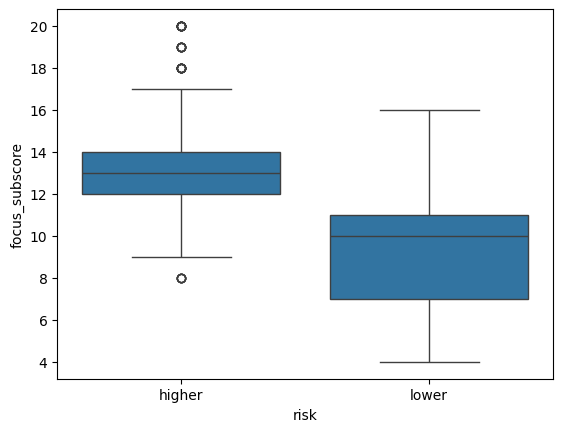

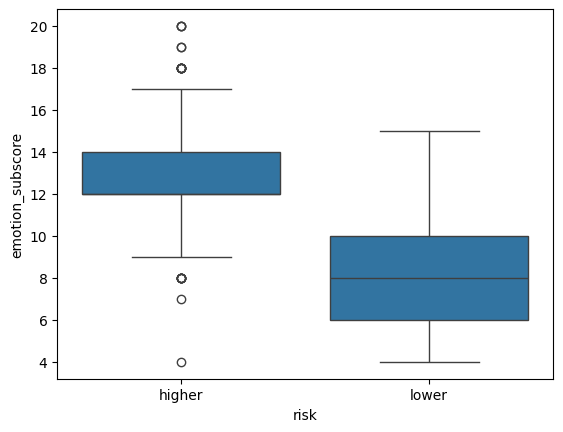

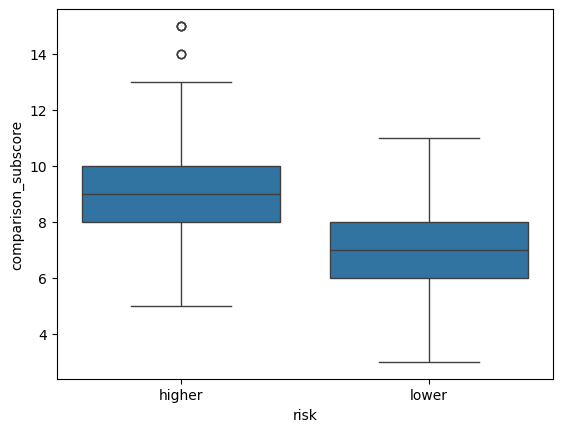

In [ ]:
sns.boxplot(x="risk", y="focus_subscore", data=df_platform); plt.show()
sns.boxplot(x="risk", y="emotion_subscore", data=df_platform); plt.show()
sns.boxplot(x="risk", y="comparison_subscore", data=df_platform); plt.show()
